# 10.5.2 有限时域LQR的Riccati倒推

## 学习目标与先修知识

从二次价值函数推导矩阵（matrix）增益（gain）和代价矩阵序列。

先修：10.5.1一步Bellman，第8篇矩阵二次型、第3篇状态空间（state space）。

## 具体问题

多变量系统经过多个时刻才到达目标。直接搜索每一时刻的输入（input）可以做小问题，但更重要的是看清为何二次价值函数能逐步向前传递，并且有限时域增益一般随时间变。

In [1]:
import math
import itertools
import ast
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

标量a=b=q=r=qf=1、N=1时，先把10.5.1的K=1/2与S₀=3/2作为矩阵递推的单元测试。

In [2]:
print("标量一步参考：K=",.5,"S0=",1.5)

标量一步参考：K= 0.5 S0= 1.5


## 模型假设

离散线性系统 $x_{t+1}=Ax_t+Bu_t$，阶段代价 $x_t^\mathsf TQx_t+u_t^\mathsf TRu_t$，终端代价 $x_N^\mathsf TQ_fx_N$。Q、Qf对称半正定（positive semidefinite），R对称正定（positive definite），输入无约束且完整状态（state）已知。目标是将状态调节到零；跟踪非零目标时，可先转换为偏差状态或补充仿射（affine）项。

## 数学解释与推导

令 $V_{t+1}(x)=x^\mathsf TS_{t+1}x$，把 $Ax+Bu$ 代入Bellman式。关于u的二次项矩阵为 $H=R+B^\mathsf TS_{t+1}B$，由R正定可逆。一阶条件给出
$$u_t^*=-K_tx_t,\quad K_t=H^{-1}B^\mathsf TS_{t+1}A.$$
代回得离散Riccati倒推
$$S_t=Q+A^\mathsf TS_{t+1}A-A^\mathsf TS_{t+1}BK_t,\quad S_N=Q_f.$$
实现时用线性方程求解K，不显式构造H的逆。S因浮点误差可对称化；还应核对维数、正定条件和小例的直接优化。有限时域的 $K_t$ 通常随t变化，不能将其无条件称为无限时域稳态增益。无限时域稳定化解的存在和有限时域倒推的收敛还需系统对 $(A,B)$ 的可稳定性（stabilizability）和代价对 $(Q^{1/2},A)$ 的可检测性（detectability）等相应条件；

## 核心实现

将刚才推导的关系逐步写成函数。

In [3]:
def finite_lqr(A, B, Q, R, terminal, horizon):
    """Finite-horizon discrete Riccati; NumPy is the only extra dependency."""
    import numpy as np
    a, b = np.asarray(A, float), np.asarray(B, float)
    q, r = np.asarray(Q, float), np.asarray(R, float)
    s = np.asarray(terminal, float)
    gains = [None] * horizon
    values = [None] * (horizon + 1)
    values[horizon] = s.tolist()
    for t in range(horizon - 1, -1, -1):
        inverse = np.linalg.solve(r + b.T @ s @ b, b.T @ s @ a)
        gains[t] = inverse.tolist()
        s = q + a.T @ s @ a - a.T @ s @ b @ inverse
        s = (s + s.T) / 2
        values[t] = s.tolist()
    return gains, values

## 对照实验

先跑标量单步测试，再对二维位置—速度型模型（model）倒推四步反馈（feedback），画增益和最优轨迹（trajectory）；另画无控制轨迹作为同初态对照。

标量一步： ([[[0.5]]], [[[1.5]], [[1.0]]])


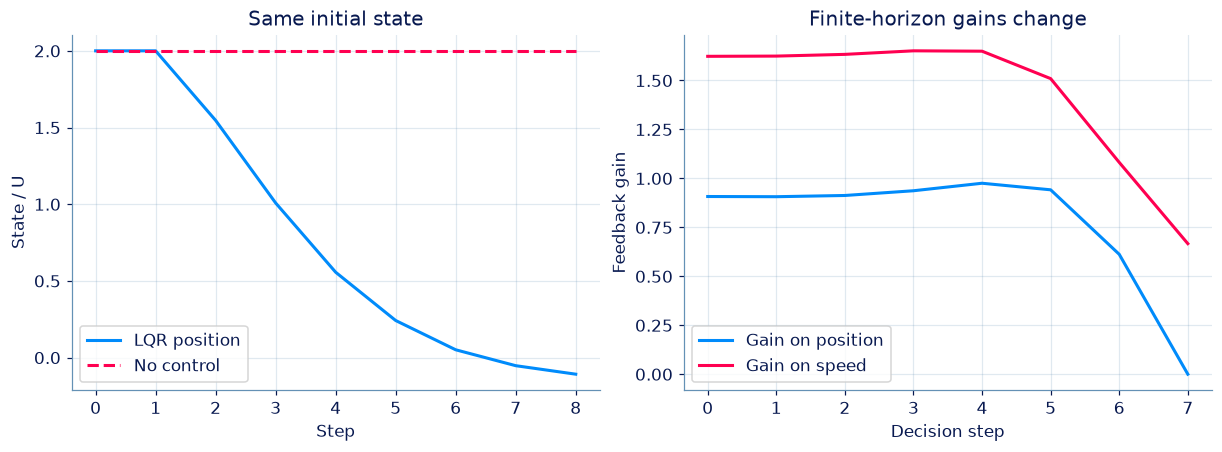

In [4]:
print('标量一步：',finite_lqr([[1.]],[[1.]],[[1.]],[[1.]],[[1.]],1))
A=np.array([[1.,.5],[0.,1.]]);B=np.array([[0.],[.5]])
Q=np.diag([1.,.1]);R=np.array([[.5]]);terminal=np.diag([2.,1.]);N=8
gains,values=finite_lqr(A.tolist(),B.tolist(),Q.tolist(),R.tolist(),terminal.tolist(),N)
K=np.array(gains)[:,0,:];x=np.array([2.,0.]);trajectory=[x.copy()];actions=[]
for t in range(N):
    u=-float(K[t]@x);actions.append(u);x=A@x+B[:,0]*u;trajectory.append(x.copy())
trajectory=np.array(trajectory);free=[np.array([2.,0.])]
for t in range(N):free.append(A@free[-1])
fig,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].plot(trajectory[:,0],label='LQR position');axes[0].plot(np.array(free)[:,0],'--',label='No control');axes[0].set(xlabel='Step',ylabel='State / U',title='Same initial state');axes[0].legend()
axes[1].plot(K[:,0],label='Gain on position');axes[1].plot(K[:,1],label='Gain on speed');axes[1].set(xlabel='Decision step',ylabel='Feedback gain',title='Finite-horizon gains change');axes[1].legend();plt.show()

## 结果解释

二维例的反馈使位置偏差逐步下降，但终端附近的增益可能明显不同于早期。这里的权重、时域与无约束输入共同决定了反馈。位置与速度单位可能不同，因此两列增益的数值不能直接当同一量比较大小。

### 独立核对

把二维结果的总直接代价与 $x_0^\mathsf TS_0x_0$ 对照；用标量N=1的解析答案核对边界。

In [5]:
np.testing.assert_allclose(finite_lqr([[1.]],[[1.]],[[1.]],[[1.]],[[1.]],1)[0][0],[[.5]],atol=1e-12)
direct=sum(trajectory[t]@Q@trajectory[t]+R[0,0]*actions[t]**2 for t in range(N))+trajectory[-1]@terminal@trajectory[-1]
start=np.array([2.,0.]);np.testing.assert_allclose(direct,start@np.array(values[0])@start,atol=1e-9)
for S in values:np.testing.assert_allclose(np.array(S),np.array(S).T,atol=1e-12)
print('直接总成本、价值函数、对称性和标量边界一致。')

直接总成本、价值函数、对称性和标量边界一致。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/10-05-%E5%8A%A8%E6%80%81%E8%A7%84%E5%88%92%E4%B8%8E%20LQR/explore/)：先预测结果，再比较图形与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：有限时域 Riccati 倒推

离散线性系统 x_next=Ax+Bu，阶段代价 xᵀQx+uᵀRu，终端代价 x_NᵀQf x_N。返回从0到N−1的反馈（feedback）增益（gain）K_t与从0到N的价值矩阵（matrix）S_t；u_t=−K_t x_t。

**函数与代码模板**

```python
def solve(
    A: list[list[float]],
    B: list[list[float]],
    Q: list[list[float]],
    R: list[list[float]],
    terminal: list[list[float]],
    horizon: int,
) -> tuple[list[list[list[float]]], list[list[list[float]]]]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `A` | `list[list[float]]` | n×n 状态（state）矩阵。 | 按状态定义 |
| `B` | `list[list[float]]` | n×m 输入（input）矩阵。 | 按状态/输入定义 |
| `Q` | `list[list[float]]` | n×n 对称半正定（positive semidefinite）阶段权重。 | 代价/状态² |
| `R` | `list[list[float]]` | m×m 对称正定（positive definite）输入权重。 | 代价/输入² |
| `terminal` | `list[list[float]]` | n×n 对称半正定终端权重。 | 代价/状态² |
| `horizon` | `int` | 正整数时域N。 | 步 |

**返回值**

按以下顺序返回元组：(gains, values)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `gains` | `list[list[list[float]]]` | 长度N，逐时刻m×n增益。 | 随状态与输入 |
| `values` | `list[list[list[float]]]` | 长度N+1的n×n代价矩阵。 | 代价/状态² |

**计算规则**

S_N=Qf；倒推 K=(R+BᵀS_next B)⁻¹ BᵀS_next A；S=Q+AᵀS_next A−AᵀS_next B K。数值上对称化S；不直接求显式逆。

**约束与边界**

- 1≤n≤3，1≤m≤2，1≤N≤8；题给矩阵满足权重条件与维度；可使用numpy。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| A | n×n 状态（state）矩阵。 | [[1.0]] | 按状态定义 |
| B | n×m 输入（input）矩阵。 | [[1.0]] | 按状态/输入定义 |
| Q | n×n 对称半正定（positive semidefinite）阶段权重。 | [[1.0]] | 代价/状态² |
| R | m×m 对称正定（positive definite）输入权重。 | [[1.0]] | 代价/输入² |
| terminal | n×n 对称半正定终端权重。 | [[1.0]] | 代价/状态² |
| horizon | 正整数时域N。 | 1 | 步 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
A = [[1.0]]
B = [[1.0]]
Q = [[1.0]]
R = [[1.0]]
terminal = [[1.0]]
horizon = 1

result = solve(A, B, Q, R, terminal, horizon)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| gains | 长度N，逐时刻m×n增益。 | [[[0.5]]] | 随状态与输入 |
| values | 长度N+1的n×n代价矩阵。 | [[[1.5]], [[1.0]]] | 代价/状态² |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([[[0.5]]], [[[1.5]], [[1.0]]])
```

**样例解释**

单步标量例K=1/2，S_0=3/2；有输入限幅时这一无约束解可能不可执行。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：有限时域 Riccati 倒推](http://127.0.0.1:8000/chapters/10-05-%E5%8A%A8%E6%80%81%E8%A7%84%E5%88%92%E4%B8%8E%20LQR/practice/?question=p10-finite-riccati)

### 第 2 题 · 单项选择题：Riccati 从哪里开始

有限时域 LQR 的倒推顺序哪项正确？

- **A.** 先设 S_N=Qf，再从t=N−1递推到0。
- **B.** 先假设所有时刻的K数值相同。
- **C.** 只需计算S_0，其他阶段无需定义。
- **D.** 把终端权重加在每个阶段而不说明。

[作答：Riccati 从哪里开始](http://127.0.0.1:8000/chapters/10-05-%E5%8A%A8%E6%80%81%E8%A7%84%E5%88%92%E4%B8%8E%20LQR/practice/?question=p10-riccati-boundary)

### 第 3 题 · 单项选择题：截断 LQR 输入

将无约束LQR计算出的u裁剪到执行上限后，哪项说法正确？

- **A.** 裁剪轨迹（trajectory）仍可作为可行基线，但一般不能称作原约束问题的最优解。
- **B.** 裁剪不改变状态（state）轨迹。
- **C.** Riccati 证明自动覆盖任何状态约束。
- **D.** 若某一步裁剪，后续最优反馈（feedback）增益（gain）必保持原结论。

[作答：截断 LQR 输入](http://127.0.0.1:8000/chapters/10-05-%E5%8A%A8%E6%80%81%E8%A7%84%E5%88%92%E4%B8%8E%20LQR/practice/?question=p10-unconstrained-vs-saturated)

### 第 4 题 · 单项选择题：时域长度改变什么

固定Q、R，改变终端权重和时域长度。最合理的预期是什么？

- **A.** 有限时域增益（gain）与价值可能变化；不能直接拿某个有限N称为无限时域稳态增益。
- **B.** K_t与N绝对无关。
- **C.** 终端条件只改变图题，不改变递推。
- **D.** 无论系统性质如何，N增大后必有相同极限（limit）。

[作答：时域长度改变什么](http://127.0.0.1:8000/chapters/10-05-%E5%8A%A8%E6%80%81%E8%A7%84%E5%88%92%E4%B8%8E%20LQR/practice/?question=p10-finite-vs-infinite)

**进一步阅读**

[MIT Underactuated Robotics：Linear Quadratic Regulators](https://underactuated.mit.edu/lqr.html)：动态规划、LQR 与有约束控制的边界；本教材的离散行动例由此处的教学目标独立设计。